In [3]:
import sys
sys.path.append("../src")

import pandas as pd
import numpy as np

from portfolio_optimizer.data_loader import (
    download_prices,
    compute_returns
)

from portfolio_optimizer.optimization import (
    baseline_lp,
    risk_constrained_lp,
    milp_rebalancing
)

from portfolio_optimizer.plots import plot_weights

[*********************100%***********************]  4 of 4 completed


  Asset  Weight
0   SPY    0.30
1   QQQ    0.35
2   TLT    0.35
3   GLD    0.00
Expected Portfolio Return: 0.1413


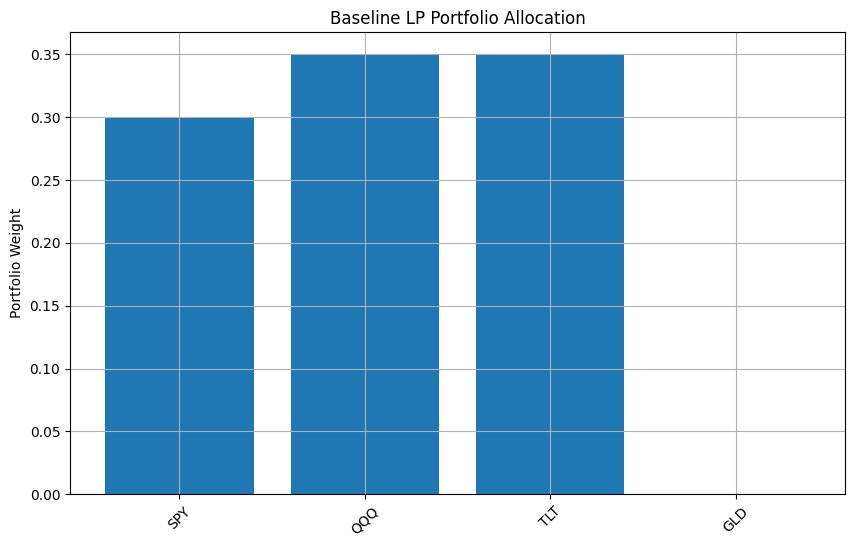

  Asset  Weight
0   SPY  0.3052
1   QQQ  0.3448
2   TLT  0.3500
3   GLD  0.0000


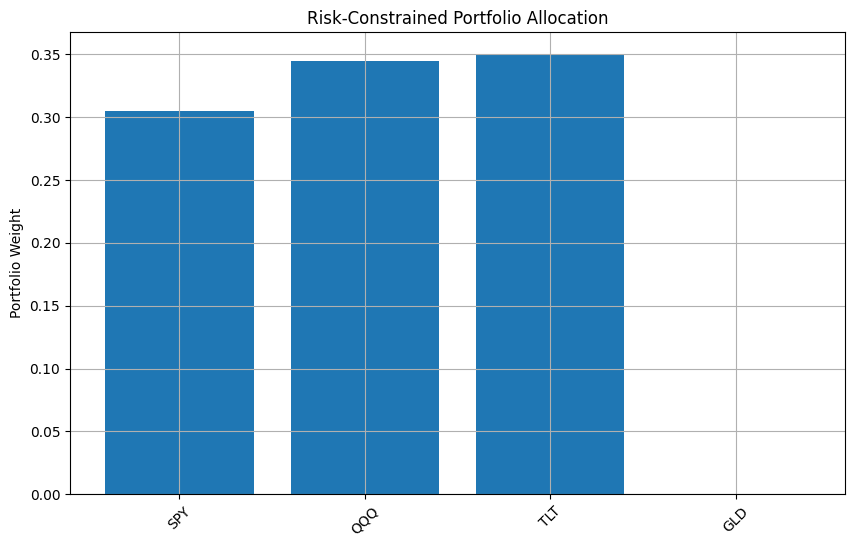

,Asset,NewWeight,Buy,Sell,Traded
0,SPY,0.30,0.05,0.00,1.0
1,QQQ,0.35,0.10,0.00,1.0
2,TLT,0.35,0.10,0.00,1.0
3,GLD,0.00,0.00,0.25,1.0


In [4]:
tickers = ["SPY", "QQQ", "TLT", "GLD"]

prices = download_prices(
    tickers,
    "2015-01-01",
    "2025-01-01"
)

returns, mean_returns, risk = compute_returns(prices)

weights, portfolio_return = baseline_lp(mean_returns)

weights_df = pd.DataFrame({
    "Asset": tickers,
    "Weight": weights
})

weights_df["Weight"] = weights_df["Weight"].round(4)

print(weights_df)

print(f"Expected Portfolio Return: {portfolio_return:.4f}")

plot_weights(
    weights,
    tickers,
    "Baseline LP Portfolio Allocation"
)

risk_weights, risk_return, risk_value = risk_constrained_lp(
    mean_returns,
    risk
)

risk_df = pd.DataFrame({
    "Asset": tickers,
    "Weight": risk_weights
})

risk_df["Weight"] = risk_df["Weight"].round(4)

print(risk_df)

plot_weights(
    risk_weights,
    tickers,
    "Risk-Constrained Portfolio Allocation"
)

current_weights = pd.Series(
    np.ones(len(tickers)) / len(tickers),
    index=tickers
)

(
    milp_weights,
    buys,
    sells,
    traded,
    milp_return
) = milp_rebalancing(
    mean_returns,
    current_weights
)

milp_df = pd.DataFrame({
    "Asset": tickers,
    "NewWeight": milp_weights,
    "Buy": buys,
    "Sell": sells,
    "Traded": traded
})

milp_df.round(4)